In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

from math import sqrt
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv('datasets\AirPassengers.csv',parse_dates=['Month'],index_col='Month')

In [5]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


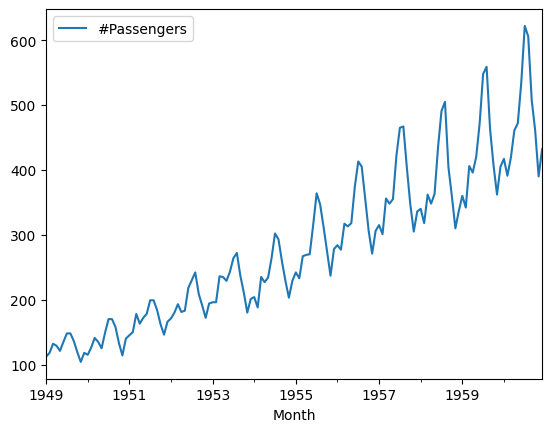

In [6]:
df.plot()
plt.show()

In [7]:
# I think this is a multiplicative time series ; moving on to decomposing each part and plotting them one by one for better understanding 

In [8]:
decomposed_df = seasonal_decompose(df['#Passengers'],model="multiplicative")

In [9]:
# we can even use the plot function directly here on the decomposed_df and set the size in inches by fetching the current figure but we will skip that for now and focus 
# on decomposing each of the time series element and moving forward 

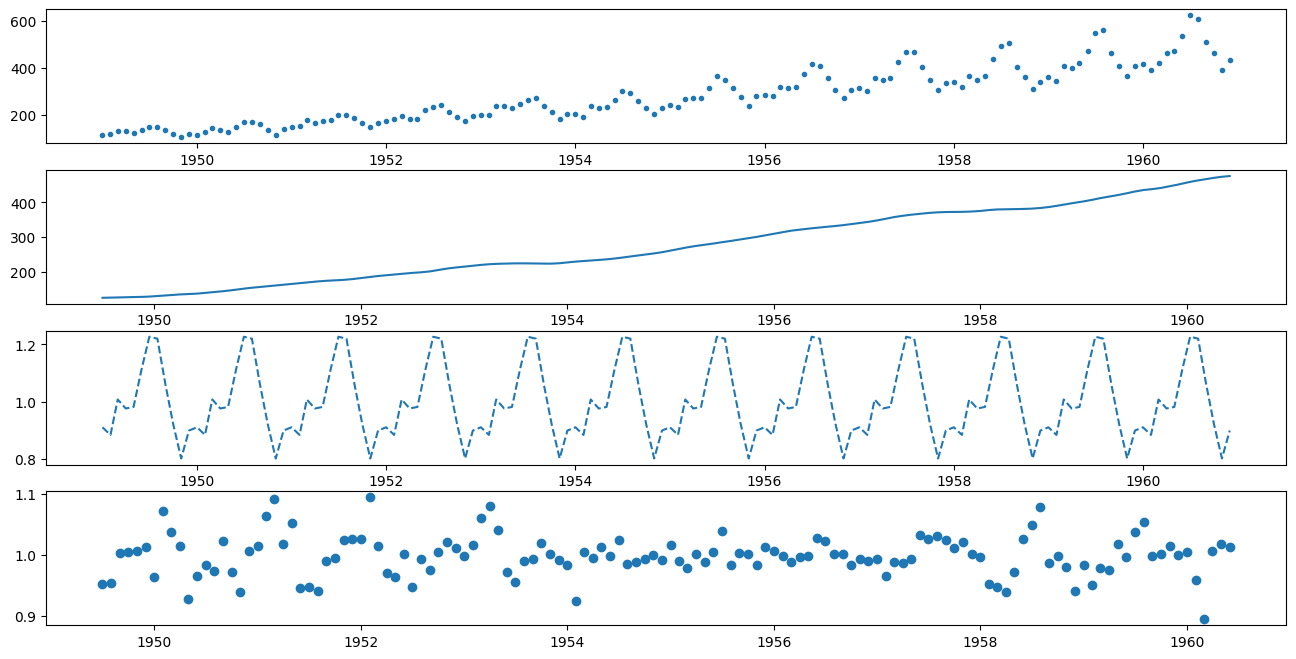

In [10]:
# We will use subplot for this tasks 

plt.figure(figsize=(16,8))

plt.subplot(411)
plt.plot(df,".")

plt.subplot(412)
plt.plot(decomposed_df.trend,'-')

plt.subplot(413)
plt.plot(decomposed_df.seasonal,'--')

plt.subplot(414)
plt.plot(decomposed_df.resid,"o")

plt.show()

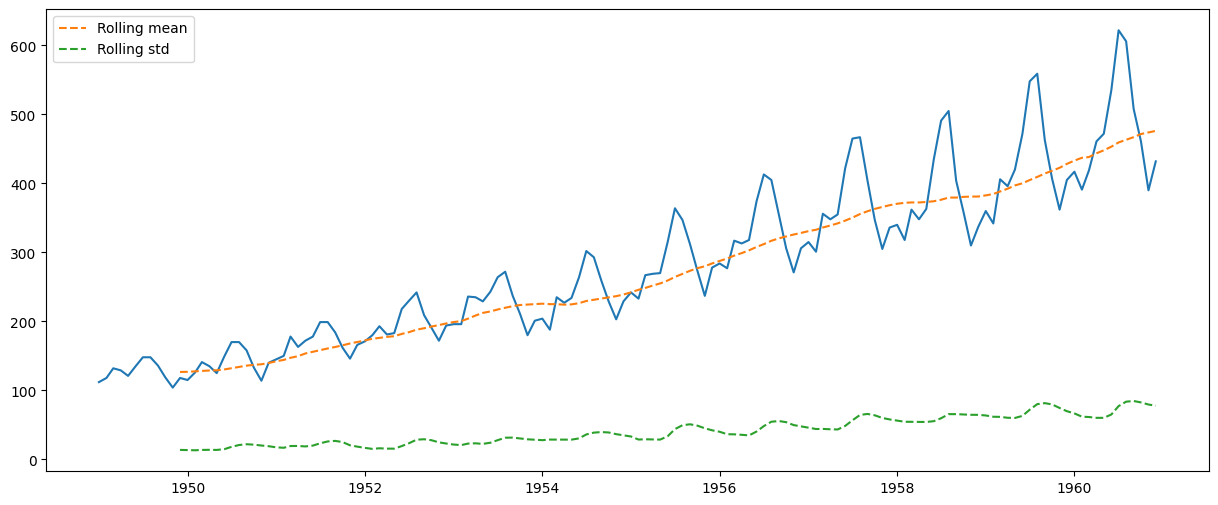

In [11]:
plt.figure(figsize=(15,6))

plt.plot(df,"-")
plt.plot(df['#Passengers'].rolling(window=12).mean(),"--",label="Rolling mean")
plt.plot(df['#Passengers'].rolling(window=12).std(),"--",label="Rolling std")

plt.legend()
plt.show()

In [12]:
# Hence this time seris is multiplicative and needs differencing or tranformation before forecasting using AR,MA,ARMA,ARIMA or SARIMA.

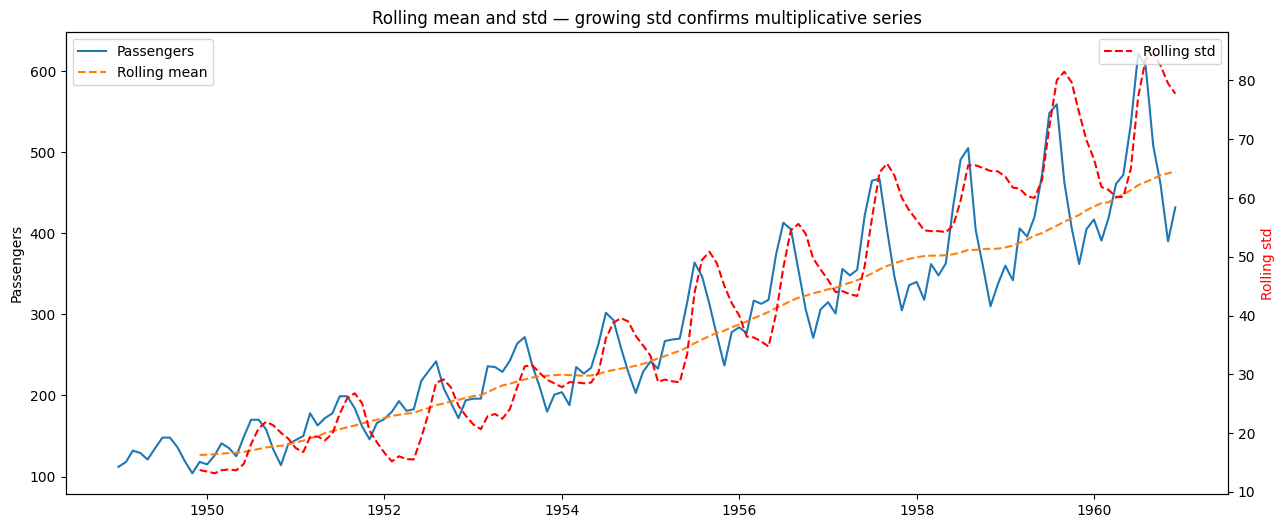

In [13]:
# A more cleaner and better graph where we twin the first axis so that we can overlap the rolling std and mean 
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(df, '-', label='Passengers')
ax1.plot(df['#Passengers'].rolling(12).mean(), '--', label='Rolling mean')
ax1.set_ylabel('Passengers')

ax2 = ax1.twinx()   # second y-axis on the right
ax2.plot(df['#Passengers'].rolling(12).std(), '--', color='red', label='Rolling std')
ax2.set_ylabel('Rolling std', color='red')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Rolling mean and std — growing std confirms multiplicative series')
plt.show()

In [ ]:
# Now we will apply log transformation to the dataset and check whether there is any change observed
y = df['#Passengers'] # Seperate the passanger columns from original dataset <-- original column without any transformation
y_log = np.log(y) # < -- Apply Log Transformation

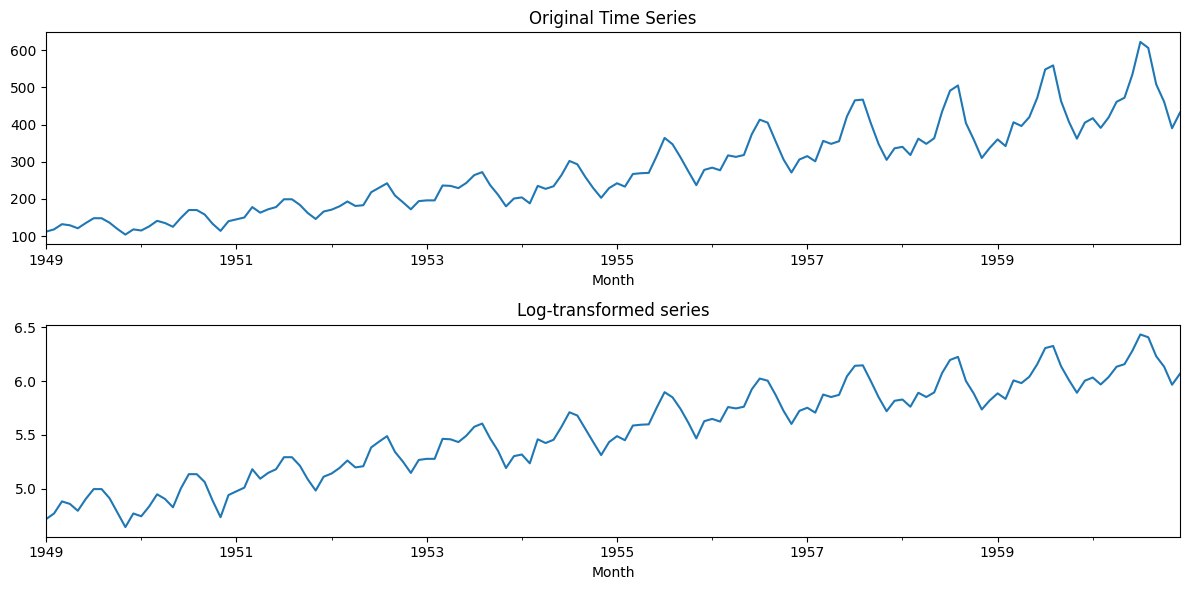

In [26]:
# Plot using the subplots to compare both the graph
plt.figure(figsize=(12,6))

plt.subplot(211)
y.plot(title="Original Time Series")

plt.subplot(212)
y_log.plot(title='Log-transformed series')
plt.tight_layout()
plt.show()

In [ ]:
# The trend peaks have become blunt but the trend still remains .

In [17]:
# Now differencing this time seris for the first time 

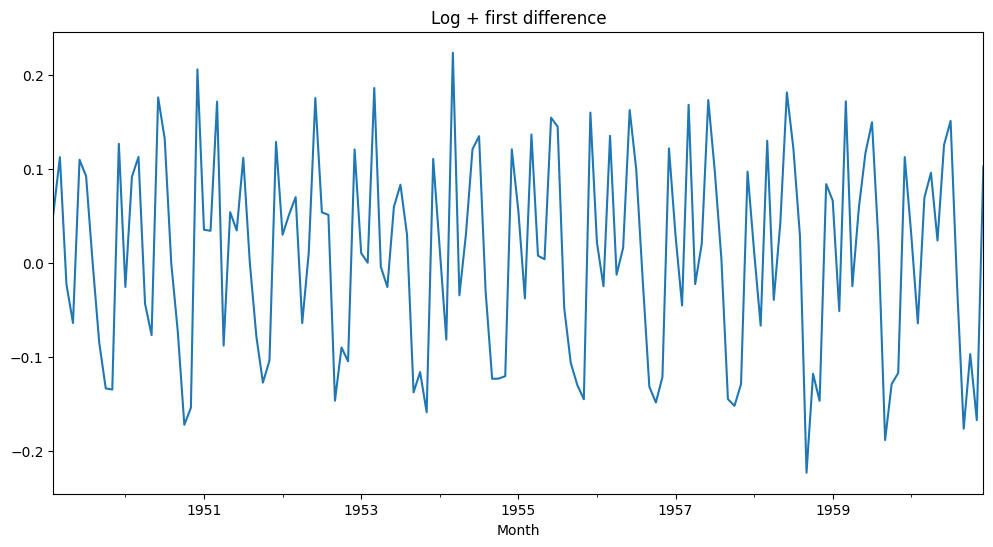

In [28]:
plt.figure(figsize=(12,6))
y_log_diff = y_log.diff().dropna() # <-- Use the diff function and afte that remove the na values.

y_log_diff.plot(title='Log + first difference')
plt.show()

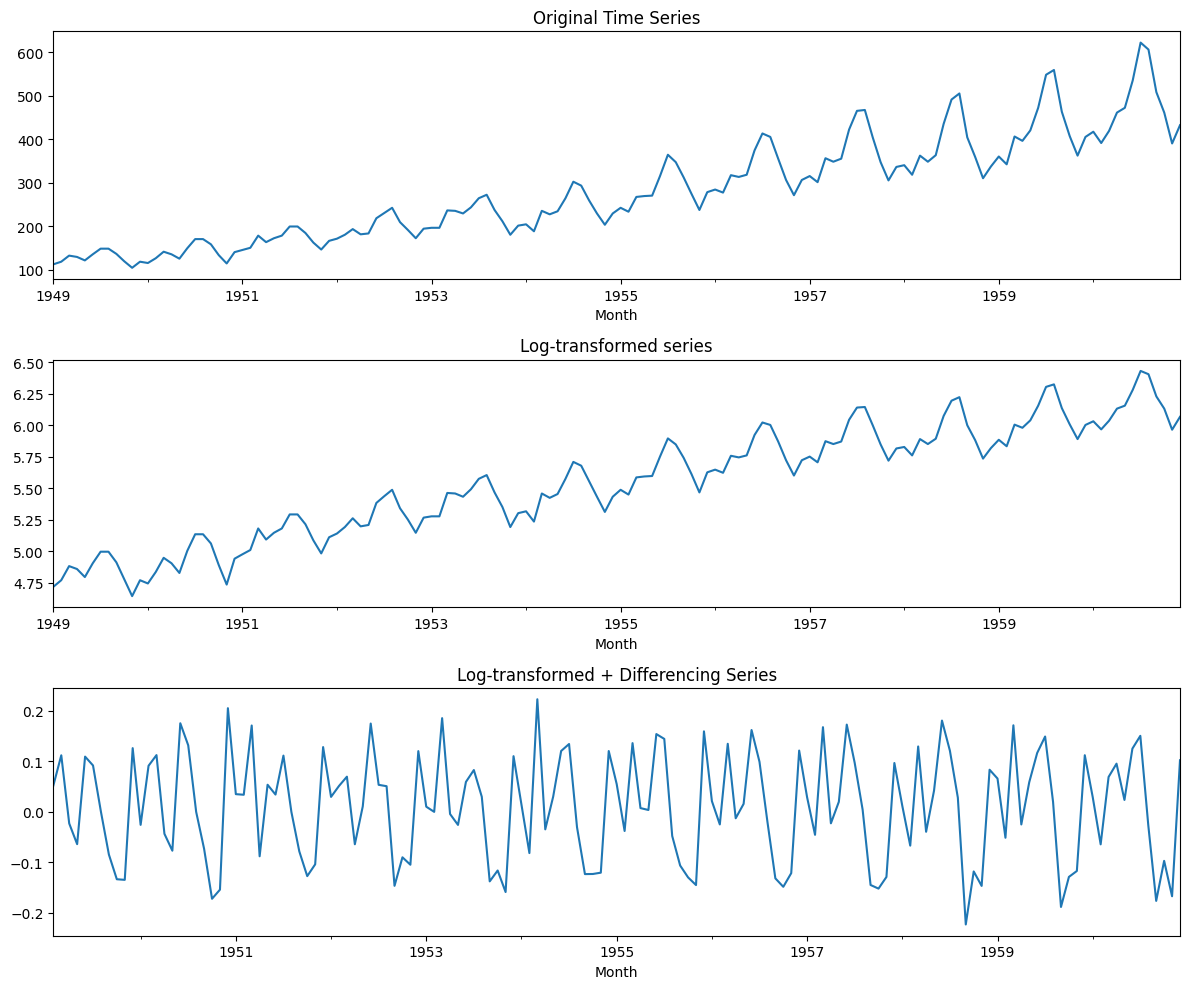

In [32]:
# Plot using the subplots to compare both the graph
plt.figure(figsize=(12,10))

plt.subplot(311)
y.plot(title="Original Time Series")

plt.subplot(312)
y_log.plot(title='Log-transformed series')

plt.subplot(313)
y_log_diff.plot(title="Log-transformed + Differencing Series")

plt.tight_layout()
plt.show()

In [19]:
# The trend seems to have been disappeared , now we will run the ADF test to confirm the significance of each stage of time seris data

In [ ]:
# Auto Dickey-Fuller Test according to me is a test to check the significance od the time series based on the p values
# Basically the p value should be less than 0.05 to be significant 
# NOTE : p-values can be chosen accordingly based on the condition and strictness.

from statsmodels.tsa.stattools import adfuller

for name, series in [('Original', y),
                     ('Log', y_log),
                     ('Log + diff', y_log_diff)]:
    result = adfuller(series.dropna())
    print(f"{name:15s} → ADF stat: {result[0]:.4f}   p-value: {result[1]:.5f}")

Original        → ADF stat: 0.8154   p-value: 0.99188
Log             → ADF stat: -1.7170   p-value: 0.42237
Log + diff      → ADF stat: -2.7171   p-value: 0.07112


In [21]:
# As we can see that the p-value even after Log+Diff the p value is still above 0.05 .
# There still exists patterns seen after eah 12 months
# We will now use SARIMA where the diff will be set to 12

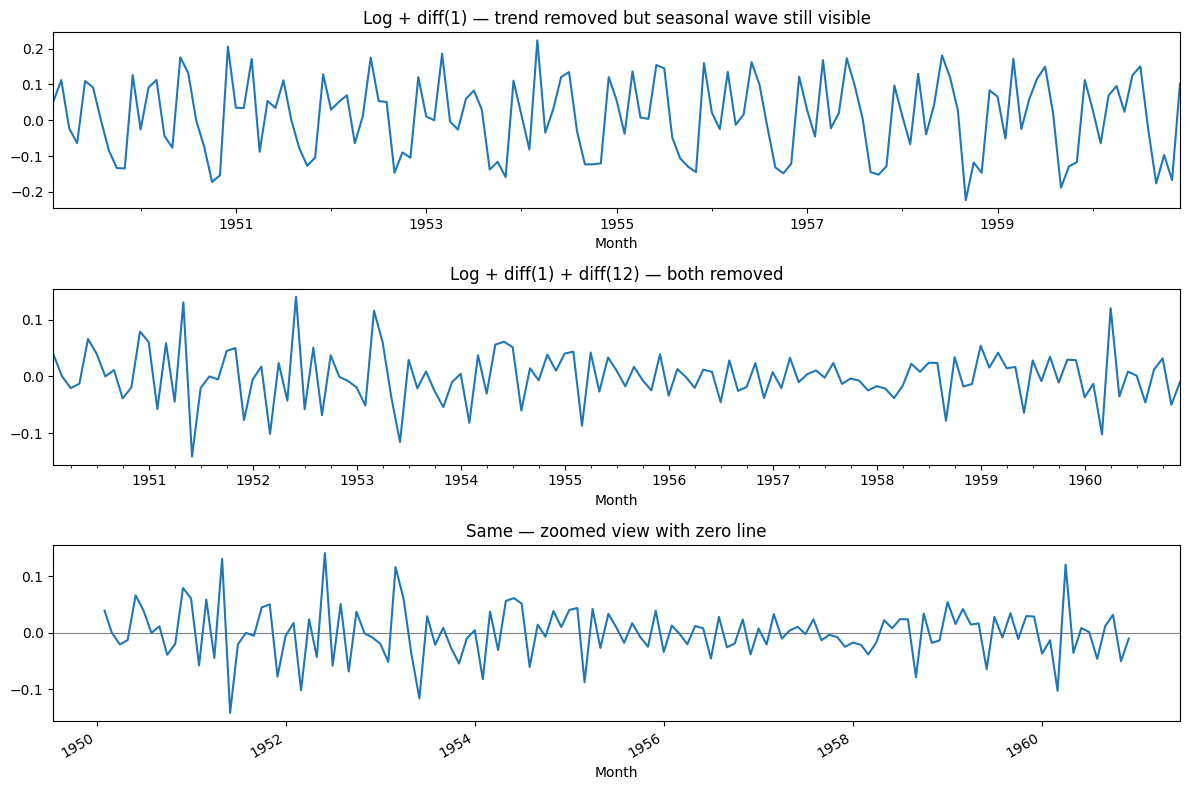

In [ ]:
# Same as before
y_log_diff = np.log(df['#Passengers']).diff().dropna()

# Now applying seasonal differencing on this differenced column
# Seasonal differencing here is basically differencing values by 12 (months)
y_log_diff_seasonal = y_log_diff.diff(12).dropna()

# Plot all three side by side to see the progression
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

np.log(df['#Passengers']).diff().dropna().plot(ax=axes[0], title='Log + diff(1) — trend removed but seasonal wave still visible')
y_log_diff_seasonal.plot(ax=axes[1], title='Log + diff(1) + diff(12) — both removed')
axes[2].axhline(0, color='gray', linewidth=0.8)  # reference line
y_log_diff_seasonal.plot(ax=axes[2], title='Same — zoomed view with zero line')

plt.tight_layout()
plt.show()

In [23]:
# Now running the ADF test again

In [24]:
y            = df['#Passengers']
y_log        = np.log(y)
y_log_d1     = y_log.diff().dropna()
y_log_d1_D1  = y_log_d1.diff(12).dropna()

for name, series in [
    ('Original',             y),
    ('Log',                  y_log),
    ('Log + diff(1)',         y_log_d1),
    ('Log + diff(1) + diff(12)', y_log_d1_D1),
]:
    result = adfuller(series.dropna())
    status = 'STATIONARY' if result[1] < 0.05 else 'Not Stationary yet'
    print(f"{name:30s}  p = {result[1]:.5f}   {status}")

Original                        p = 0.99188   Not Stationary yet
Log                             p = 0.42237   Not Stationary yet
Log + diff(1)                   p = 0.07112   Not Stationary yet
Log + diff(1) + diff(12)        p = 0.00025   STATIONARY


In [34]:
# Finally we know have a significant time series which can be used for forecasting using AR,MA or both based on the ACF and PACF graph